In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [55]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [56]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [57]:
df.shape

(891, 15)

In [58]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [59]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [61]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [62]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [63]:
df.duplicated().sum()

107

In [64]:
df = df.drop_duplicates()

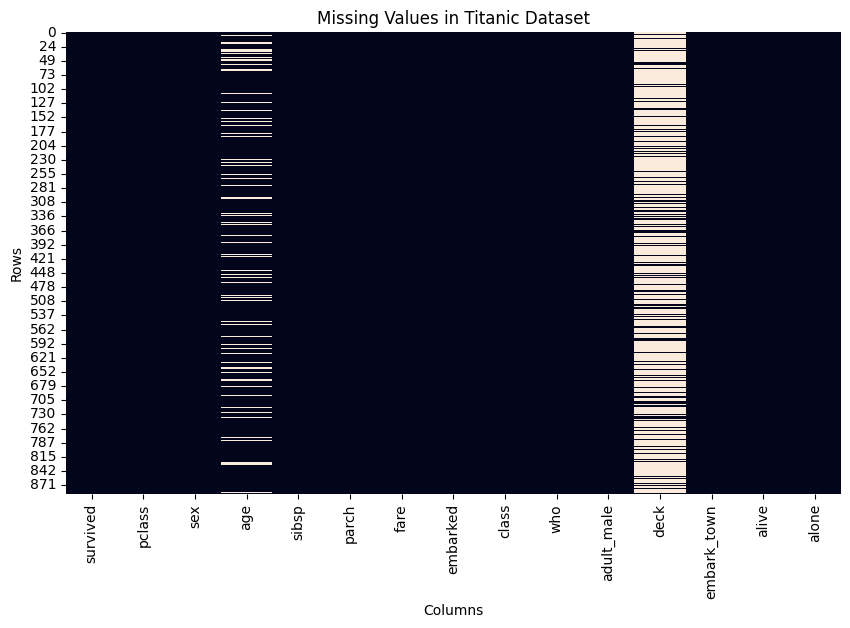

In [65]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Titanic Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

In [66]:
df["age"] = df["age"].fillna(df["age"].median())

In [67]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [98]:
df = df.drop_duplicates()
print("Duplicates after removal:", df.duplicated().sum())

Duplicates after removal: 0


In [99]:
df["embark_town"] = df["embark_town"].fillna(
    df["embark_town"].mode()[0]
)

In [125]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [126]:
df.dtypes

survived          int64
pclass         category
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

In [103]:
df["sex"] = df["sex"].astype("category")
df["embarked"] = df["embarked"].astype("category")

In [104]:
df["pclass"] = df["pclass"].astype("category")

In [105]:
df.dtypes

survived          int64
pclass         category
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked       category
class          category
who              object
adult_male         bool
embark_town      object
alive            object
alone              bool
dtype: object

In [106]:
df.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [107]:
df.describe()

,survived,age,sibsp,parch,fare
count,780.000000,780.000000,780.000000,780.000000,780.000000
mean,0.412821,29.604385,0.525641,0.417949,34.829108
std,0.492657,13.719131,0.988046,0.838536,52.263440
min,0.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,21.750000,0.000000,0.000000,8.050000
50%,0.000000,28.250000,0.000000,0.000000,15.950000
75%,1.000000,36.000000,1.000000,1.000000,34.375000
max,1.000000,80.000000,8.000000,6.000000,512.329200


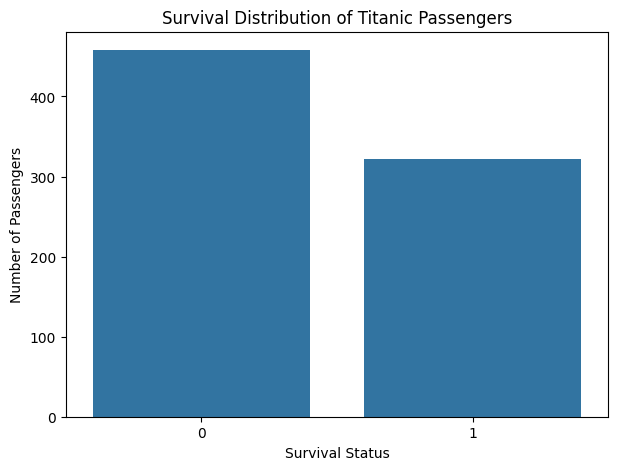

In [108]:
plt.figure(figsize=(7, 5))

sns.countplot(x="survived", data=df)

plt.title("Survival Distribution of Titanic Passengers")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()

In [109]:
df["survived"].value_counts()

0    458
1    322
Name: survived, dtype: int64

In [110]:
survival_rate = df["survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.2f}%")

Overall survival rate: 41.28%


In [111]:
df.groupby("sex")["survived"].value_counts()

sex     survived
female  1           216
        0            76
male    0           382
        1           106
Name: survived, dtype: int64

In [112]:
gender_survival = df.groupby("sex")["survived"].mean() * 100

print(gender_survival)

sex
female    73.972603
male      21.721311
Name: survived, dtype: float64


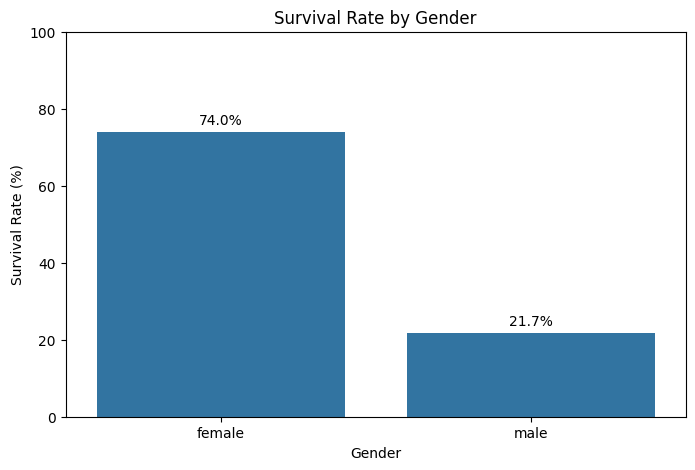

In [113]:
gender_survival = df.groupby("sex")["survived"].mean() * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=gender_survival.index,
    y=gender_survival.values
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(gender_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

In [114]:
df.groupby("pclass")["survived"].mean() * 100

pclass
1    63.679245
2    50.609756
3    25.742574
Name: survived, dtype: float64

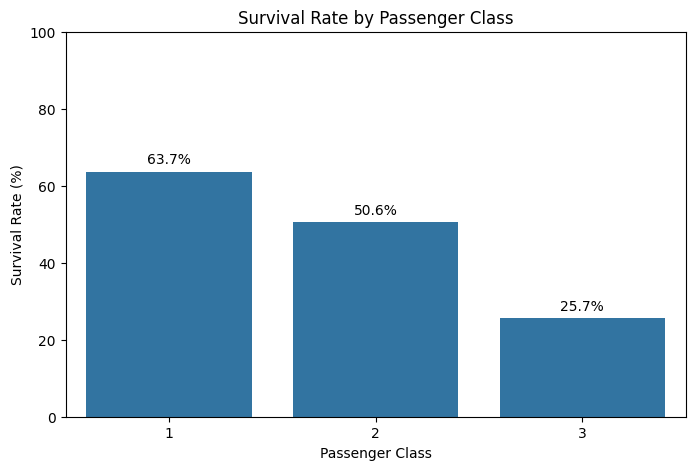

In [115]:
class_survival = df.groupby("pclass")["survived"].mean() * 100

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=class_survival.index.astype(str),
    y=class_survival.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)

for i, value in enumerate(class_survival.values):
    ax.text(i, value + 2, f"{value:.1f}%", ha="center")

plt.show()

In [116]:
df["age"].describe()

count    780.000000
mean      29.604385
std       13.719131
min        0.420000
25%       21.750000
50%       28.250000
75%       36.000000
max       80.000000
Name: age, dtype: float64

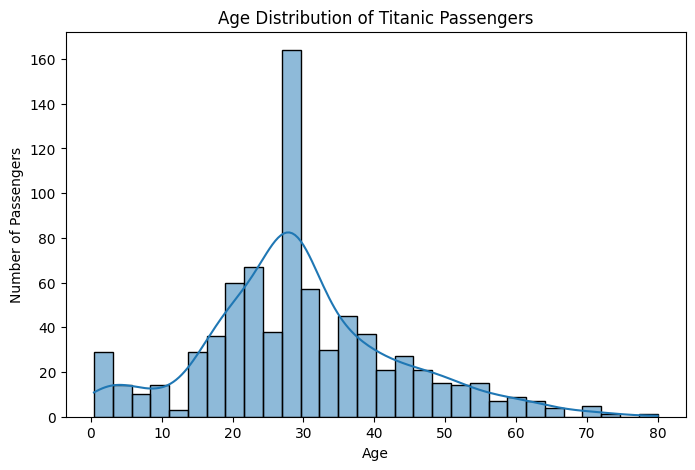

In [117]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

In [118]:
df["fare"].describe()

count    780.000000
mean      34.829108
std       52.263440
min        0.000000
25%        8.050000
50%       15.950000
75%       34.375000
max      512.329200
Name: fare, dtype: float64

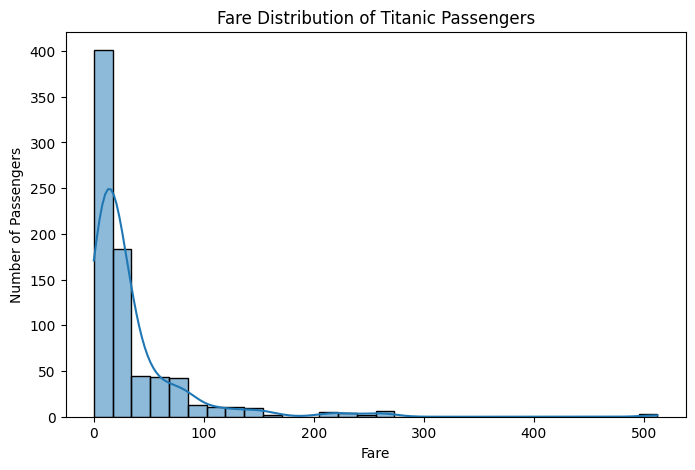

In [119]:
plt.figure(figsize=(8, 5))

sns.histplot(df["fare"], bins=30, kde=True)

plt.title("Fare Distribution of Titanic Passengers")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

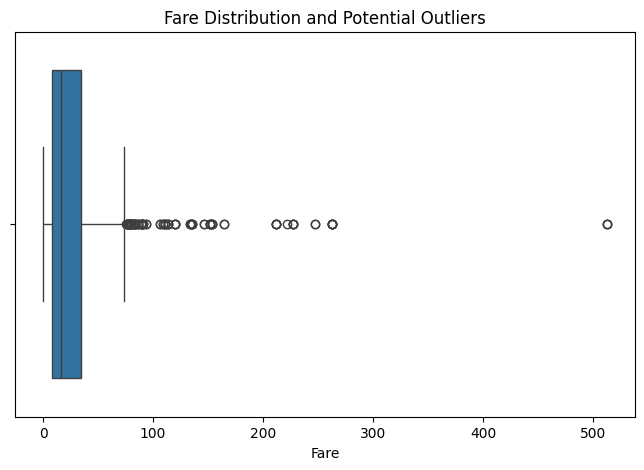

In [120]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["fare"])

plt.title("Fare Distribution and Potential Outliers")
plt.xlabel("Fare")

plt.show()

In [121]:
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()
correlation

,survived,age,sibsp,parch,fare
survived,1.000000,-0.078050,-0.037597,0.069669,0.246669
age,-0.078050,1.000000,-0.278886,-0.182903,0.092280
sibsp,-0.037597,-0.278886,1.000000,0.380596,0.134127
parch,0.069669,-0.182903,0.380596,1.000000,0.191055
fare,0.246669,0.092280,0.134127,0.191055,1.000000


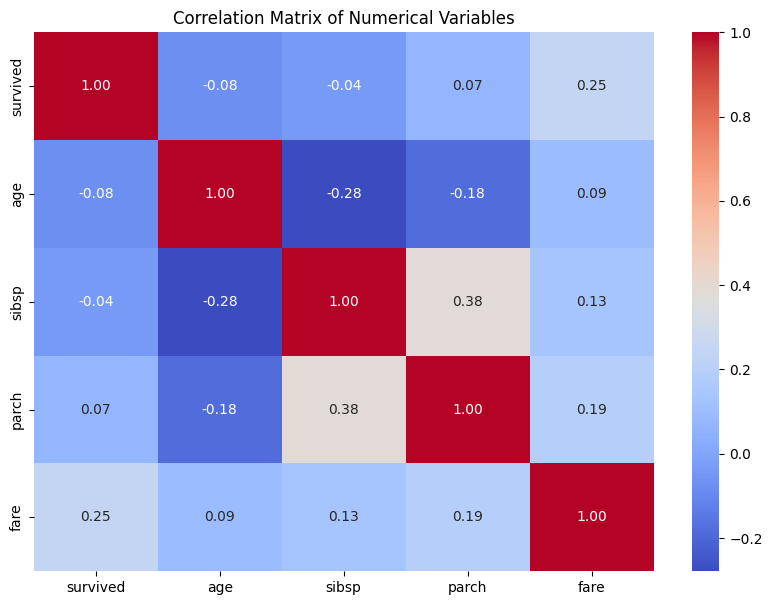

In [122]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [123]:
print("=" * 50)
print("WEEK 1 FINAL RESULTS")
print("=" * 50)

print("\nDataset Shape:")
print(df.shape)

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nOverall Survival Rate:")
print(f"{df['survived'].mean() * 100:.2f}%")

print("\nSurvival Rate by Gender:")
print(
    (df.groupby("sex", observed=True)["survived"].mean() * 100)
    .round(2)
)

print("\nSurvival Rate by Passenger Class:")
print(
    (df.groupby("pclass", observed=True)["survived"].mean() * 100)
    .round(2)
)

print("\nAge Statistics:")
print(df["age"].describe().round(2))

print("\nFare Statistics:")
print(df["fare"].describe().round(2))

WEEK 1 FINAL RESULTS

Dataset Shape:
(780, 14)

Duplicate Rows:
0

Missing Values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

Overall Survival Rate:
41.28%

Survival Rate by Gender:
sex
male      21.72
female    73.97
Name: survived, dtype: float64

Survival Rate by Passenger Class:
pclass
3    25.74
1    63.68
2    50.61
Name: survived, dtype: float64

Age Statistics:
count    780.00
mean      29.60
std       13.72
min        0.42
25%       21.75
50%       28.25
75%       36.00
max       80.00
Name: age, dtype: float64

Fare Statistics:
count    780.00
mean      34.83
std       52.26
min        0.00
25%        8.05
50%       15.95
75%       34.38
max      512.33
Name: fare, dtype: float64
